0. Импорты и чтение

In [1]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

df = pd.read_excel(Path("../data/Maternal Health Risk Data Set.xlsx"))
df.head()

c:\Users\user\miniconda3\envs\main\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


1. Что вообще лежит в таблице

In [2]:
print(df.shape)
print(df.dtypes)
print("пропуски:\n", df.isna().sum())
print("уникальных значений:\n", df.nunique())
print("полных дублей строк:", df.duplicated().sum())
df.describe()

(1014, 7)
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object
пропуски:
 Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64
уникальных значений:
 Age            50
SystolicBP     19
DiastolicBP    16
BS             29
BodyTemp        8
HeartRate      16
RiskLevel       3
dtype: int64
полных дублей строк: 562


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


2. Таргет

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64
RiskLevel
low risk     0.400
mid risk     0.331
high risk    0.268
Name: proportion, dtype: float64


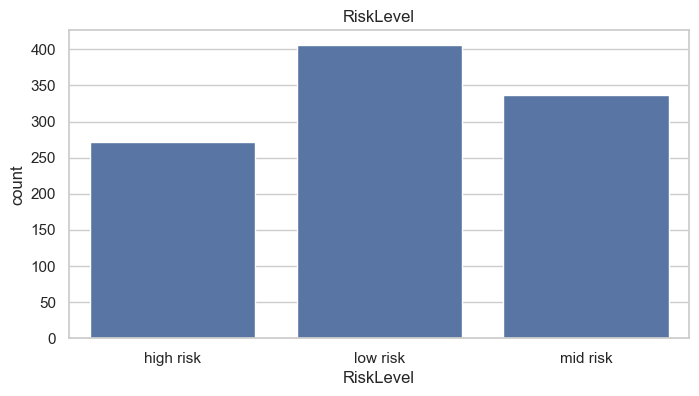

In [3]:
print(df["RiskLevel"].value_counts())
print(df["RiskLevel"].value_counts(normalize=True).round(3))

sns.countplot(data=df, x="RiskLevel")
plt.title("RiskLevel")
plt.show()

3. Дубли — сколько уникальных профилей

In [4]:
print("строк:", len(df))
print("уникальных:", df.drop_duplicates().shape[0])
print("лишних копий:", df.duplicated().sum())

df.value_counts().head(15)

строк: 1014
уникальных: 452
лишних копий: 562


Age  SystolicBP  DiastolicBP  BS    BodyTemp  HeartRate  RiskLevel
19   120         80           7.0   98.0      70         mid risk     27
48   120         80           11.0  98.0      88         high risk    14
31   120         60           6.1   98.0      76         mid risk     13
40   160         100          19.0  98.0      77         high risk    10
55   140         95           19.0  98.0      77         high risk    10
32   140         90           18.0  98.0      88         high risk     9
54   140         100          15.0  98.0      66         high risk     9
32   120         90           7.5   98.0      70         low risk      7
40   120         95           11.0  98.0      80         high risk     7
31   120         60           6.1   98.0      76         low risk      7
19   120         80           7.0   98.0      70         low risk      7
42   120         80           7.5   98.0      70         low risk      7
29   130         70           7.5   98.0      78         

Дальше смотрим уникальные строки, иначе гистограммы раздуты копиями.

In [5]:
u = df.drop_duplicates().copy()
print(u.shape)
u["RiskLevel"].value_counts()

(452, 7)


RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64

4. Какие значения принимают признаки

In [6]:
for c in u.columns:
    vals = np.sort(u[c].unique()) if np.issubdtype(u[c].dtype, np.number) else u[c].unique()
    print(f"\n{c}: {u[c].nunique()} уникальных | min={u[c].min() if np.issubdtype(u[c].dtype, np.number) else ''} max={u[c].max() if np.issubdtype(u[c].dtype, np.number) else ''}")
    print(vals if len(vals) <= 30 else list(vals[:15]) + ["..."] + list(vals[-8:]))


Age: 50 уникальных | min=10 max=70
[np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), '...', np.int64(56), np.int64(59), np.int64(60), np.int64(62), np.int64(63), np.int64(65), np.int64(66), np.int64(70)]

SystolicBP: 19 уникальных | min=70 max=160
[ 70  75  76  78  80  83  85  90  95  99 100 110 115 120 129 130 135 140
 160]

DiastolicBP: 16 уникальных | min=49 max=100
[ 49  50  60  63  65  68  69  70  75  76  80  85  89  90  95 100]

BS: 29 уникальных | min=6.0 max=19.0
[ 6.    6.1   6.3   6.4   6.5   6.6   6.7   6.8   6.9   7.    7.01  7.1
  7.2   7.5   7.6   7.7   7.8   7.9   8.    9.   10.   11.   12.   13.
 15.   16.   17.   18.   19.  ]

BodyTemp: 8 уникальных | min=98.0 max=103.0
[ 98.   98.4  98.6  99.  100.  101.  102.  103. ]

HeartRate: 16 уникальных | min=7 max=90
[ 7 60 65 66 67 68 70 75 76 77 78 80 82 86 88 90]



5. Распределения

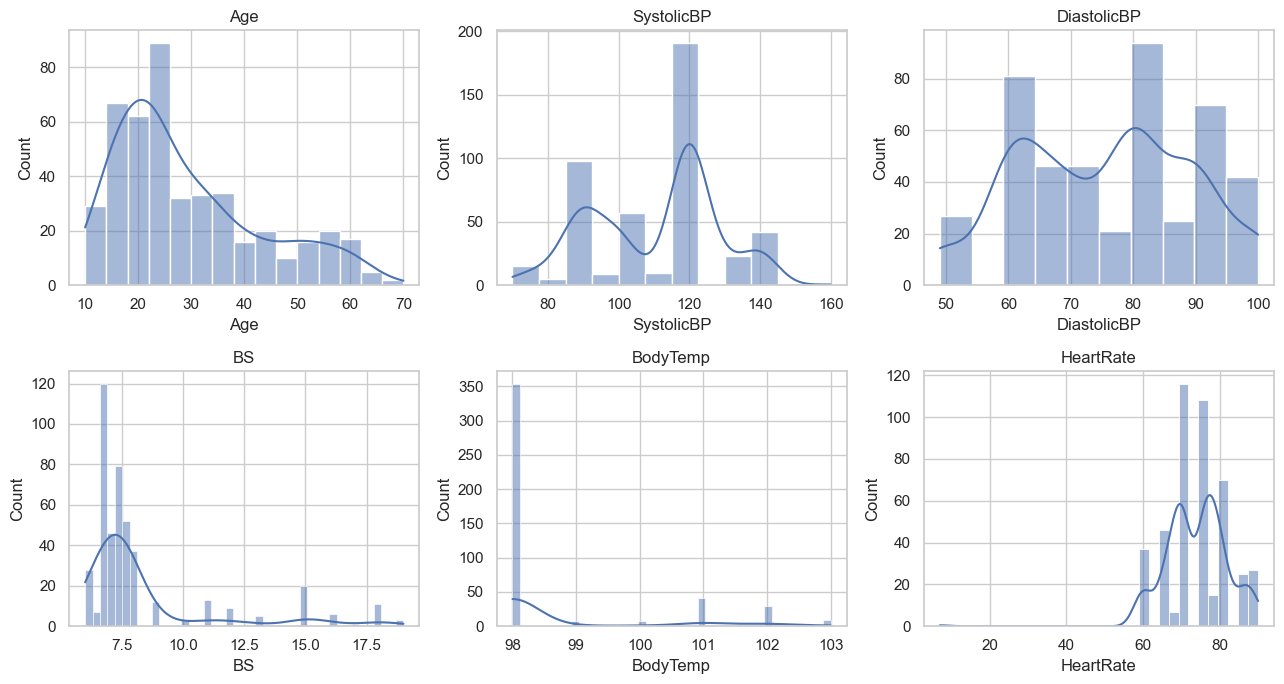

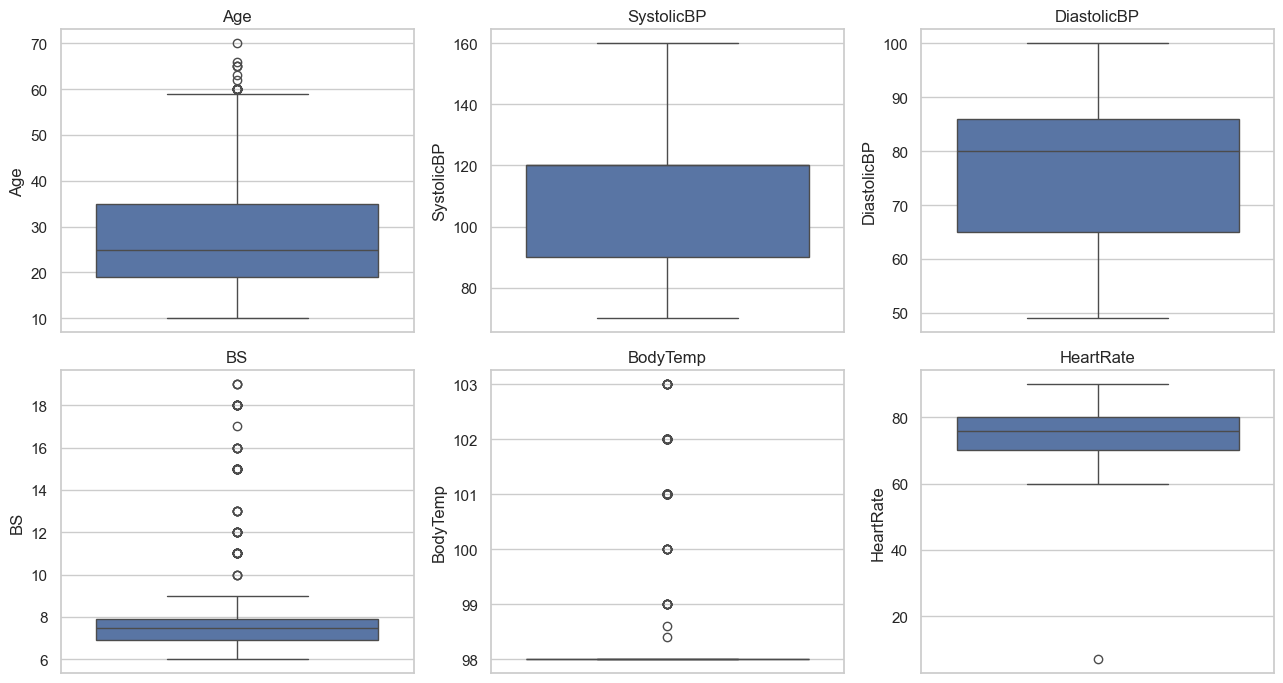

In [7]:
num = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), num):
    sns.histplot(u[c], kde=True, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), num):
    sns.boxplot(y=u[c], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

6. Кто на хвостах

In [8]:
for c in num:
    print("\n===", c, "===")
    display(u.nsmallest(3, c)[num + ["RiskLevel"]])
    display(u.nlargest(3, c)[num + ["RiskLevel"]])


=== Age ===


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
19,10,70,50,6.9,98.0,70,low risk
250,10,85,65,6.9,98.0,70,low risk
670,10,100,50,6.0,99.0,70,mid risk


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
338,70,85,60,6.9,102.0,70,low risk
326,66,85,60,6.9,98.0,86,low risk
322,65,90,60,6.9,98.0,70,low risk



=== SystolicBP ===


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
19,10,70,50,6.9,98.0,70,low risk
505,17,70,50,7.9,98.0,70,low risk
535,16,70,50,7.5,100.0,70,low risk


...

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
3,30,140,85,7.0,98.0,70,high risk


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
191,17,90,65,6.1,103.0,67,high risk
287,17,90,65,7.7,103.0,67,high risk
337,45,120,80,6.9,103.0,70,low risk



=== HeartRate ===


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
35,12,95,60,6.1,102.0,60,low risk
41,23,120,90,6.1,98.0,60,low risk


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
16,50,140,90,15.0,98.0,90,high risk
20,40,140,100,18.0,98.0,90,high risk
102,48,140,90,15.0,98.0,90,high risk


7. Как признаки выглядят по классам

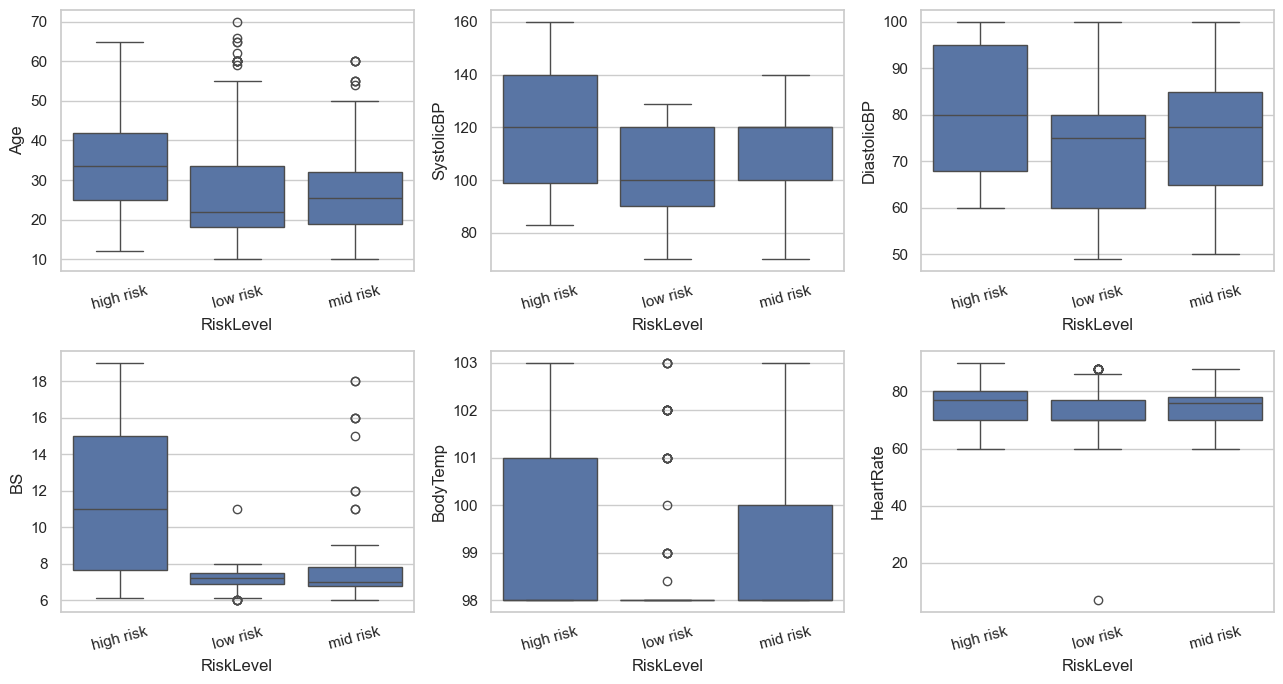

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
high risk,33.5,120.0,80.0,11.0,98.0,77.0
low risk,22.0,100.0,75.0,7.2,98.0,70.0
mid risk,25.5,120.0,77.5,7.0,98.0,76.0


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), num):
    sns.boxplot(data=u, x="RiskLevel", y=c, ax=ax)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

u.groupby("RiskLevel")[num].median()

8. Корреляции

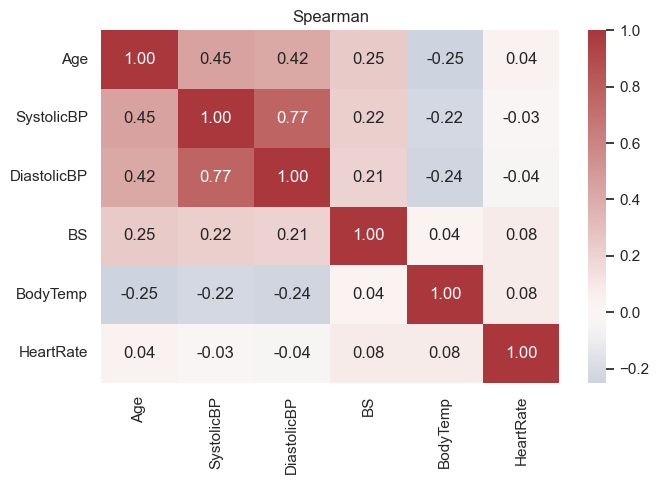

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(u[num].corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
plt.title("Spearman")
plt.tight_layout()
plt.show()

9. Связь с риском

In [11]:
tmp = u.copy()
tmp["y"] = tmp["RiskLevel"].map({"low risk": 0, "mid risk": 1, "high risk": 2})
tmp[num + ["y"]].corr(method="spearman")["y"].drop("y").sort_values(ascending=False)

BS             0.416919
SystolicBP     0.313080
BodyTemp       0.266924
DiastolicBP    0.222473
Age            0.218472
HeartRate      0.171974
Name: y, dtype: float64

Убираем дубли

In [12]:
print("исходно:", df.shape)
print(df["RiskLevel"].value_counts(), "\n")

clean = df.drop_duplicates().copy()
print("после дублей:", clean.shape)
print(clean["RiskLevel"].value_counts())

исходно: (1014, 7)
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64 

после дублей: (452, 7)
RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64


Выкидываем артефакт пульс 7

In [13]:
print(clean["HeartRate"].describe())
display(clean[clean["HeartRate"] < 40])

clean = clean[clean["HeartRate"] >= 40].reset_index(drop=True)
print("после фильтра:", clean.shape)
print(clean["RiskLevel"].value_counts())

count    452.000000
mean      73.949115
std        8.156973
min        7.000000
25%       70.000000
50%       76.000000
75%       80.000000
max       90.000000
Name: HeartRate, dtype: float64


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk


после фильтра: (451, 7)
RiskLevel
low risk     233
high risk    112
mid risk     106
Name: count, dtype: int64


Контрольный EDA на уже чистых 451

(451, 7)
дублей: 0
min HeartRate: 60
RiskLevel
low risk     233
high risk    112
mid risk     106
Name: count, dtype: int64 

RiskLevel
low risk     51.7
high risk    24.8
mid risk     23.5
Name: proportion, dtype: float64


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,451.00,451.00,451.00,451.00,451.00,451.00
mean,29.22,110.53,75.42,8.35,98.69,74.10
std,13.77,17.89,13.77,2.83,1.41,7.53
min,10.00,70.00,49.00,6.00,98.00,60.00
25%,19.00,90.00,65.00,6.90,98.00,70.00
50%,25.00,120.00,80.00,7.50,98.00,76.00
75%,35.00,120.00,87.00,7.90,98.00,80.00
max,70.00,160.00,100.00,19.00,103.00,90.00


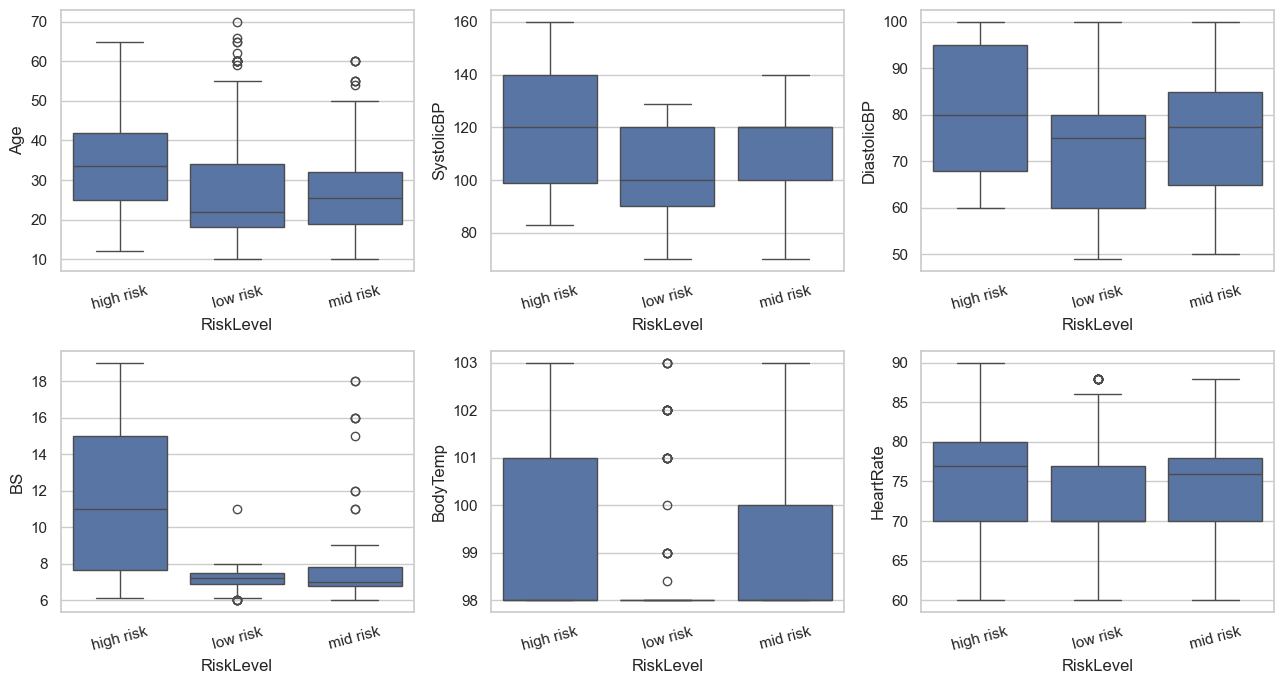

In [14]:
num = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]

print(clean.shape)
print("дублей:", clean.duplicated().sum())
print("min HeartRate:", clean["HeartRate"].min())
print(clean["RiskLevel"].value_counts(), "\n")
print((clean["RiskLevel"].value_counts(normalize=True) * 100).round(1))
display(clean.describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), num):
    sns.boxplot(data=clean, x="RiskLevel", y=c, ax=ax)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

Сохраняем подготовленные датасеты

In [15]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    clean, test_size=0.2, stratify=clean["RiskLevel"], random_state=42
)

def show_balance(name, data):
    vc = data["RiskLevel"].value_counts()
    pct = data["RiskLevel"].value_counts(normalize=True) * 100
    print(f"\n{name}: {len(data)} строк")
    for cls, n in vc.items():
        print(f"  {cls:10s}  {n:3d}  ({pct[cls]:5.1f}%)")

show_balance("train", train_df)
show_balance("test", test_df)

train_df.to_csv("../data/train.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)


train: 360 строк
  low risk    186  ( 51.7%)
  high risk    89  ( 24.7%)
  mid risk     85  ( 23.6%)

test: 91 строк
  low risk     47  ( 51.6%)
  high risk    23  ( 25.3%)
  mid risk     21  ( 23.1%)
